In [ ]:
##IMPORTING NECESSARY LIBRARIES

from google.colab import files
import zipfile
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix

IMPORTING DATASET...


Saving archive.zip to archive (5).zip
Dataset uploaded
   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  


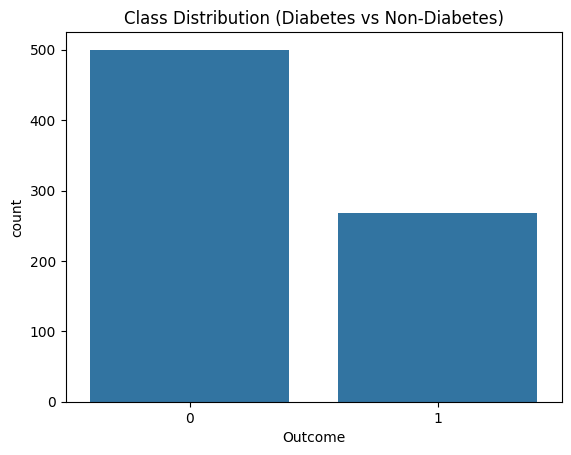

In [ ]:
## IMPORTING DATASET

print("IMPORTING DATASET...")
uploaded = files.upload()

with zipfile.ZipFile("archive.zip", 'r') as zip_ref:
  zip_ref.extractall()

# Load the dataset
df = pd.read_csv("diabetes.csv")

print("Dataset uploaded")
print(df.head())

# Visualize class distribution
sns.countplot(x='Outcome', data=df)
plt.title("Class Distribution (Diabetes vs Non-Diabetes)")
plt.show()

In [ ]:
## PREPROCESSING THE DATASET


# Replace zero values in certain columns with NaN
columns_to_fix = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
df[columns_to_fix] = df[columns_to_fix].replace(0, np.nan)

# Fill missing values with median
df.fillna(df.median(), inplace=True)

# Confirm no missing values
print("\nMissing Values After Imputation:")
print(df.isnull().sum())

# Define features (X) and target (y)
X = df.drop(columns=['Outcome'])  # Features
y = df['Outcome']  # Target (Diabetes or Not)

# Split into training & test sets (80-20 split)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Apply feature scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)



Missing Values After Imputation:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64


In [ ]:

## Logistic Regression Model

log_reg = LogisticRegression()
log_reg.fit(X_train, y_train)

# Predictions & Accuracy
y_pred_lr = log_reg.predict(X_test)
accuracy_lr = accuracy_score(y_test, y_pred_lr)

print("\n Logistic Regression Results:")
print(f"Accuracy: {accuracy_lr:.2f}")
print(classification_report(y_test, y_pred_lr))


 Logistic Regression Results:
Accuracy: 0.75
              precision    recall  f1-score   support

           0       0.80      0.83      0.81        99
           1       0.67      0.62      0.64        55

    accuracy                           0.75       154
   macro avg       0.73      0.72      0.73       154
weighted avg       0.75      0.75      0.75       154




 SVM Results:
Accuracy: 0.75
              precision    recall  f1-score   support

           0       0.78      0.84      0.81        99
           1       0.67      0.58      0.62        55

    accuracy                           0.75       154
   macro avg       0.72      0.71      0.72       154
weighted avg       0.74      0.75      0.74       154



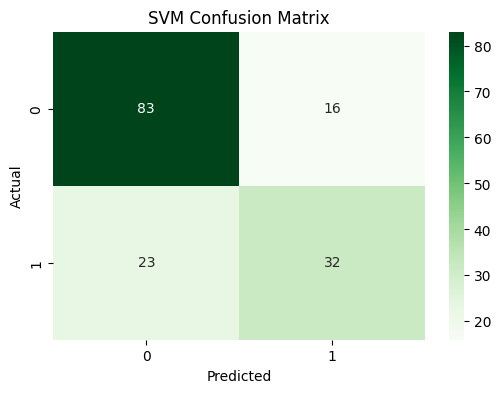

In [ ]:
## Support Vector Machine

svm_model = SVC()
svm_model.fit(X_train, y_train)

# Predictions & Accuracy
y_pred_svm = svm_model.predict(X_test)
accuracy_svm = accuracy_score(y_test, y_pred_svm)

print("\n SVM Results:")
print(f"Accuracy: {accuracy_svm:.2f}")
print(classification_report(y_test, y_pred_svm))


# Confusion Matrix for SVM
plt.figure(figsize=(6,4))
sns.heatmap(confusion_matrix(y_test, y_pred_svm), annot=True, fmt='d', cmap='Greens')
plt.title("SVM Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()



 KNN Results:
Accuracy: 0.72
              precision    recall  f1-score   support

           0       0.80      0.75      0.77        99
           1       0.60      0.67      0.63        55

    accuracy                           0.72       154
   macro avg       0.70      0.71      0.70       154
weighted avg       0.73      0.72      0.72       154



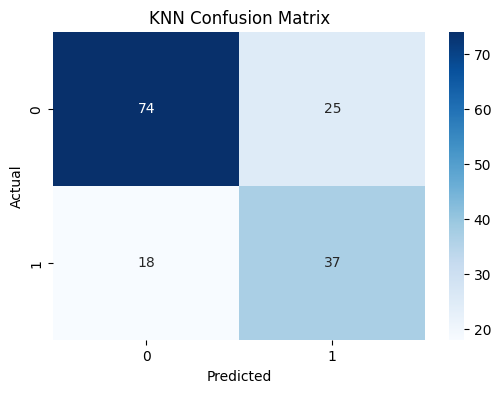

In [ ]:
# K-Nearest Neighbors (KNN) Model

# Initialize KNN with default K=5
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)

# Predictions & Accuracy
y_pred_knn = knn.predict(X_test)
accuracy_knn = accuracy_score(y_test, y_pred_knn)

print("\n KNN Results:")
print(f"Accuracy: {accuracy_knn:.2f}")
print(classification_report(y_test, y_pred_knn))

# Confusion Matrix for KNN
plt.figure(figsize=(6,4))
sns.heatmap(confusion_matrix(y_test, y_pred_knn), annot=True, fmt='d', cmap='Blues')
plt.title("KNN Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [ ]:
#  Grid Search for Hyperparameter Tuning (SVM)

param_grid = {
    'C': [0.1, 1, 10],
    'kernel': ['linear', 'rbf', 'poly'],
    'gamma': ['scale', 'auto']
}

grid_search = GridSearchCV(SVC(), param_grid, cv=5, scoring='accuracy', n_jobs=-1)
grid_search.fit(X_train, y_train)

# Best Parameters & Accuracy
print("\n Best Parameters for SVM using Grid Search:")
print(grid_search.best_params_)
print(f"Best Grid Search Accuracy: {grid_search.best_score_:.2f}")

# Evaluate SVM with Best Found Parameters
best_svm = grid_search.best_estimator_
y_pred_best_svm = best_svm.predict(X_test)
accuracy_best_svm = accuracy_score(y_test, y_pred_best_svm)

print("\n Tuned SVM Results:")
print(f"Accuracy After Tuning: {accuracy_best_svm:.2f}")
print(classification_report(y_test, y_pred_best_svm))



 Best Parameters for SVM using Grid Search:
{'C': 1, 'gamma': 'scale', 'kernel': 'linear'}
Best Grid Search Accuracy: 0.77

 Tuned SVM Results:
Accuracy After Tuning: 0.75
              precision    recall  f1-score   support

           0       0.80      0.83      0.81        99
           1       0.67      0.62      0.64        55

    accuracy                           0.75       154
   macro avg       0.73      0.72      0.73       154
weighted avg       0.75      0.75      0.75       154




 Best Parameters for KNN using Grid Search:
{'metric': 'manhattan', 'n_neighbors': 7, 'weights': 'uniform'}
Best Grid Search Accuracy: 0.77

 Tuned KNN Results:
Accuracy After Tuning: 0.73
              precision    recall  f1-score   support

           0       0.80      0.77      0.78        99
           1       0.61      0.65      0.63        55

    accuracy                           0.73       154
   macro avg       0.71      0.71      0.71       154
weighted avg       0.73      0.73      0.73       154



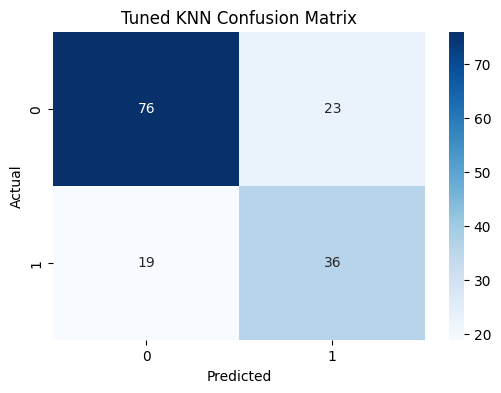

In [ ]:
#  Hyperparameter Tuning with Grid Search (KNN)


param_grid = {
    'n_neighbors': [3, 5, 7, 9, 11, 13],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']
}

grid_search_knn = GridSearchCV(KNeighborsClassifier(), param_grid, cv=5, scoring='accuracy', n_jobs=-1)
grid_search_knn.fit(X_train, y_train)

# Best Parameters & Accuracy
print("\n Best Parameters for KNN using Grid Search:")
print(grid_search_knn.best_params_)
print(f"Best Grid Search Accuracy: {grid_search_knn.best_score_:.2f}")

# Evaluate KNN with Best Found Parameters
best_knn = grid_search_knn.best_estimator_
y_pred_best_knn = best_knn.predict(X_test)
accuracy_best_knn = accuracy_score(y_test, y_pred_best_knn)

print("\n Tuned KNN Results:")
print(f"Accuracy After Tuning: {accuracy_best_knn:.2f}")
print(classification_report(y_test, y_pred_best_knn))

# Confusion matrix for best KNN
plt.figure(figsize=(6,4))
sns.heatmap(confusion_matrix(y_test, y_pred_best_knn), annot=True, fmt='d', cmap='Blues')
plt.title("Tuned KNN Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [ ]:
# Compare Performance (Tuned Models)
print("\n📊 Performance Comparison (Tuned Models):")
print(f"Tuned KNN Accuracy: {accuracy_best_knn:.2f}")
print(f"Tuned SVM Accuracy: {accuracy_best_svm:.2f}")

if accuracy_best_svm > accuracy_best_knn:
    print("\n✅ SVM is better than KNN based on accuracy!")
else:
    print("\n❌ KNN performed better, but this is unlikely in this dataset.")



📊 Performance Comparison (Tuned Models):
Tuned KNN Accuracy: 0.73
Tuned SVM Accuracy: 0.75

✅ SVM is better than KNN based on accuracy!
